## Libraries

In [153]:
import json
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from tqdm import tqdm
from scipy.stats import spearmanr
from sklearn.metrics import mean_absolute_error, f1_score, cohen_kappa_score

## Helper macros

In [154]:
DIMENSIONS = ['Noise', 'Sharpness', 'Details', 'Dynamic Range', 'Exposure', 
              'Contrast', 'Banding', 'White Balance', 'Saturation', 'Ghost']

SCORE_TO_LABEL = {
    -2: "Motorola < Monalisa",
    -1: "Motorola =< Monalisa",
    0:  "Motorola = Monalisa",
    1:  "Motorola => Monalisa",
    2:  "Motorola > Monalisa"
}

LABELS = [-2, -1, 0, 1, 2]

def label_to_score(val):
    
    if pd.isna(val): return np.nan
    val = str(val).strip()
    if '=>' in val or '>=' in val: return 1
    if '=<' in val or '<=' in val: return -1
    if '<' in val: return -2
    if '>' in val: return 2
    if '=' in val: return 0
    return np.nan

In [155]:
def load_evaluation_data(pred_csv_path, gt_xlsx_path):

    df_gt = pd.read_excel(gt_xlsx_path, skiprows=7)
    df_gt['scene_id'] = df_gt['Scene'].apply(lambda x: str(x).zfill(3))
    
    # Load Predictions
    df_preds = pd.read_csv(pred_csv_path)
    df_preds['scene_id'] = df_preds['scene_id'].apply(lambda x: str(x).zfill(3))

    # Merge dataframes
    df_merged = pd.merge(df_gt, df_preds, on='scene_id', suffixes=('_gt', '_pred'))
    
    return df_merged

## Output

In [156]:
def calculate_goodness_metrics(model_name, df_eval):

    records = []
    
    for dim in DIMENSIONS:
        y_true = df_eval[f'{dim}_gt'].apply(label_to_score)
        y_pred = df_eval[f'{dim}_pred'].apply(label_to_score)
        
        mask = ~y_true.isna() & ~y_pred.isna()
        y_true, y_pred = y_true[mask].values, y_pred[mask].values

        if len(y_true) > 0:
            diff = np.abs(y_true - y_pred)
            
            top1 = np.mean(diff <= 0)
            top2 = np.mean(diff <= 1)
            top3 = np.mean(diff <= 2)
            directional_acc = np.mean(np.sign(y_true) == np.sign(y_pred))
            
            srcc, _ = spearmanr(y_true, y_pred) if len(set(y_true)) > 1 else (0.0, 0.0)
            kappa = cohen_kappa_score(y_true.astype(int), y_pred.astype(int), 
                                      weights='quadratic', labels=[-2, -1, 0, 1, 2])

            records.append({
                'Model': model_name,
                'Dimension': dim,
                'Top1_Acc': top1,
                'Top2_Acc': top2,
                'Top3_Acc': top3,
                'Directional_Acc': directional_acc,
                'MAE': mean_absolute_error(y_true, y_pred),
                'SRCC': srcc,
                'Weighted_Kappa': kappa,
                'F1': f1_score(y_true, y_pred, average='macro', labels=[-2, -1, 0, 1, 2])
            })

    return records

def run_experiments(inputs_path : str = 'results_Qwen7B', gt_file='TCL_evaluation_dataset.xlsx'):

    all_results_list = []
    
    # Loop through prediction files
    for file_name in os.listdir(inputs_path):
        if not file_name.endswith('.csv'): continue
            
        model_name = file_name.replace('.csv', '')
        full_pred_path = os.path.join(inputs_path, file_name)
        
        df_eval = load_evaluation_data(full_pred_path, gt_file)
        
        model_records = calculate_goodness_metrics(model_name, df_eval)
        all_results_list.extend(model_records)

    # Aggregate into final DataFrames
    df_results = pd.DataFrame(all_results_list)
    
    df_summary = df_results.groupby('Model').agg({
        'Top1_Acc': 'mean', 'Top2_Acc': 'mean', 'Top3_Acc': 'mean', 'Directional_Acc' : 'mean',
        'MAE': 'mean', 'SRCC': 'mean', 'Weighted_Kappa': 'mean', 'F1': 'mean'
    }).reset_index().sort_values(by='Weighted_Kappa', ascending=False)

    return df_results, df_summary

def run_master_evaluation(folder_list, gt_file='TCL_evaluation_dataset.xlsx'):

    all_results = []
    
    for folder in folder_list:
        if not os.path.exists(folder): continue
        
        for file_name in os.listdir(folder):
            if not file_name.endswith('.csv'): continue
            
            model_label = f"{folder.replace('results_', '')}_{file_name.replace('.csv', '')}"
            full_path = os.path.join(folder, file_name)
            
            # Use your existing data loading function
            df_eval = load_evaluation_data(full_path, gt_file)
            
            # Calculate metrics
            model_records = calculate_goodness_metrics(model_label, df_eval)
            all_results.extend(model_records)

    df_detailed = pd.DataFrame(all_results)
    
    df_summary = df_detailed.groupby('Model').mean(numeric_only=True).reset_index()
    df_summary = df_summary.sort_values(by='Weighted_Kappa', ascending=False)

    return df_detailed, df_summary

In [157]:
df_results_Qwen, df_summary_Qwen = run_experiments("results_Qwen7B")

c:\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Python\Python310\lib\site-packa

In [158]:
df_results_Gemini, df_summary_Gemini = run_experiments("results_big_LLM")

c:\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Python\Python310\lib\site-packa

In [159]:
df_all_dims, df_leaderboard = run_master_evaluation(["results_Qwen7B", "results_big_LLM"])

c:\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Python\Python310\lib\site-packa

## Agreement between models

In [160]:
def plot_pivot(pivot_table, name : str):
    plt.figure(figsize=(14, 8))

    sns.heatmap(
        pivot_table, 
        annot=True,     
        cmap="YlGnBu", 
        linewidths=.5,  
        cbar_kws={'label': 'Directional Accuracy (Sign Match)'}
    )

    plt.title(f"Model {name} vs Dimensions", fontsize=15, pad=20)
    plt.xlabel("IQA Dimension", fontsize=12)
    plt.ylabel("Model Configuration", fontsize=12)
    plt.tight_layout()
    plt.show()

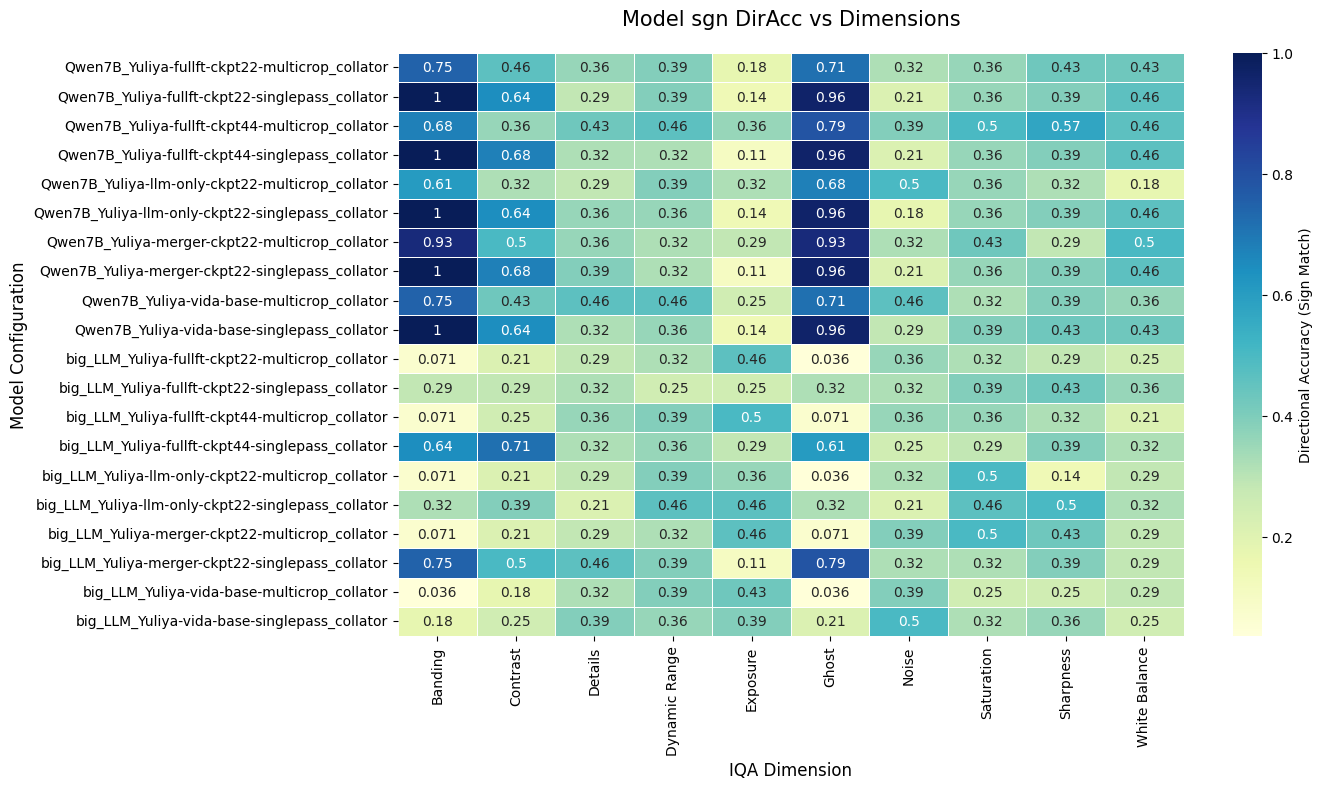

Dimension,Banding,Contrast,Details,Dynamic Range,Exposure,Ghost,Noise,Saturation,Sharpness,White Balance
Model,,,,,,,,,,
Qwen7B_Yuliya-fullft-ckpt22-multicrop_collator,0.750,0.464,0.357,0.393,0.179,0.714,0.321,0.357,0.429,0.429
Qwen7B_Yuliya-fullft-ckpt22-singlepass_collator,1.000,0.643,0.286,0.393,0.143,0.964,0.214,0.357,0.393,0.464
Qwen7B_Yuliya-fullft-ckpt44-multicrop_collator,0.679,0.357,0.429,0.464,0.357,0.786,0.393,0.500,0.571,0.464
Qwen7B_Yuliya-fullft-ckpt44-singlepass_collator,1.000,0.679,0.321,0.321,0.107,0.964,0.214,0.357,0.393,0.464
Qwen7B_Yuliya-llm-only-ckpt22-multicrop_collator,0.607,0.321,0.286,0.393,0.321,0.679,0.500,0.357,0.321,0.179
Qwen7B_Yuliya-llm-only-ckpt22-singlepass_collator,1.000,0.643,0.357,0.357,0.143,0.964,0.179,0.357,0.393,0.464
Qwen7B_Yuliya-merger-ckpt22-multicrop_collator,0.929,0.500,0.357,0.321,0.286,0.929,0.321,0.429,0.286,0.500
Qwen7B_Yuliya-merger-ckpt22-singlepass_collator,1.000,0.679,0.393,0.321,0.107,0.964,0.214,0.357,0.393,0.464
Qwen7B_Yuliya-vida-base-multicrop_collator,0.750,0.429,0.464,0.464,0.250,0.714,0.464,0.321,0.393,0.357


In [161]:
pivot_table = df_all_dims.pivot(index='Dimension', columns='Model', values='Directional_Acc').T.round(3)
plot_pivot(pivot_table, name = 'sgn DirAcc')
pivot_table

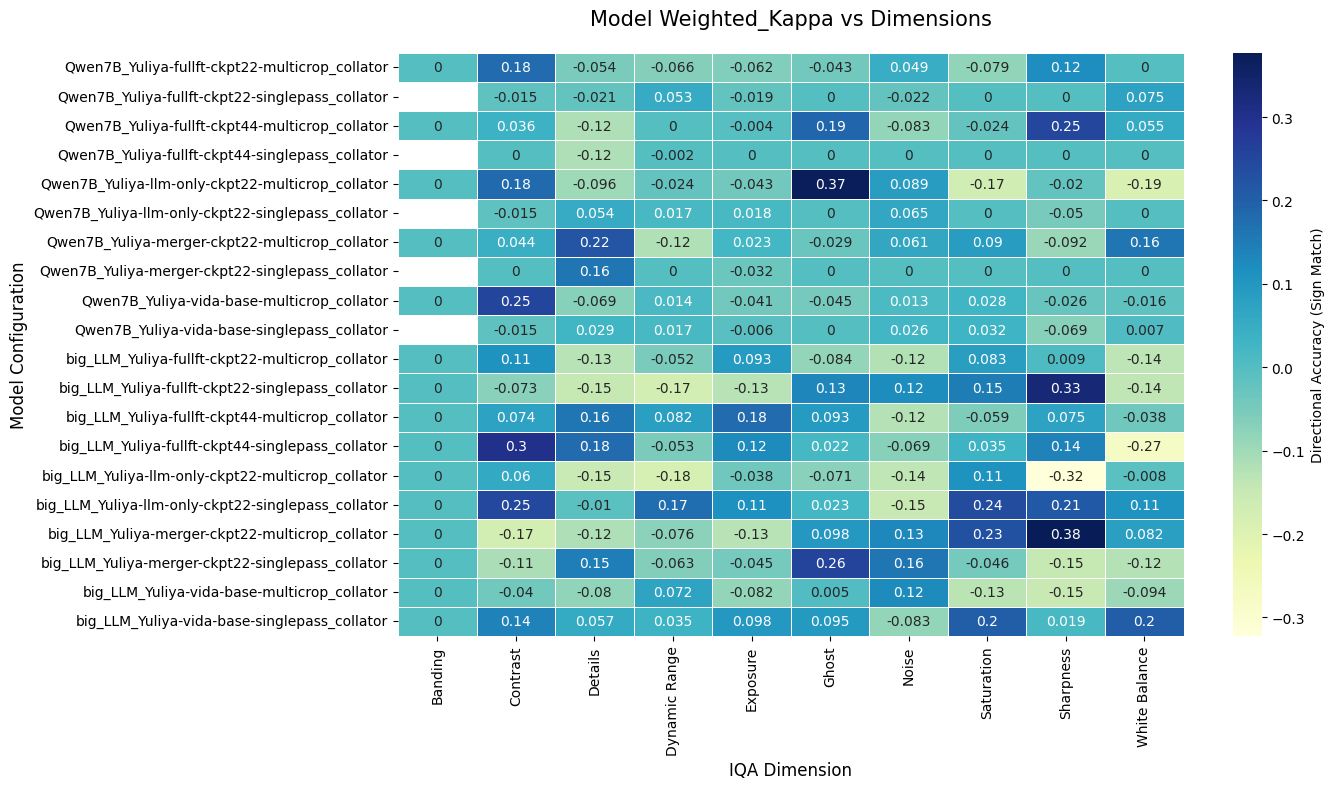

Dimension,Banding,Contrast,Details,Dynamic Range,Exposure,Ghost,Noise,Saturation,Sharpness,White Balance
Model,,,,,,,,,,
Qwen7B_Yuliya-fullft-ckpt22-multicrop_collator,0.0,0.178,-0.054,-0.066,-0.062,-0.043,0.049,-0.079,0.120,0.000
Qwen7B_Yuliya-fullft-ckpt22-singlepass_collator,NaN,-0.015,-0.021,0.053,-0.019,0.000,-0.022,0.000,0.000,0.075
Qwen7B_Yuliya-fullft-ckpt44-multicrop_collator,0.0,0.036,-0.117,0.000,-0.004,0.188,-0.083,-0.024,0.251,0.055
Qwen7B_Yuliya-fullft-ckpt44-singlepass_collator,NaN,0.000,-0.116,-0.002,0.000,0.000,0.000,0.000,0.000,0.000
Qwen7B_Yuliya-llm-only-ckpt22-multicrop_collator,0.0,0.183,-0.096,-0.024,-0.043,0.373,0.089,-0.167,-0.020,-0.187
Qwen7B_Yuliya-llm-only-ckpt22-singlepass_collator,NaN,-0.015,0.054,0.017,0.018,0.000,0.065,0.000,-0.050,0.000
Qwen7B_Yuliya-merger-ckpt22-multicrop_collator,0.0,0.044,0.221,-0.119,0.023,-0.029,0.061,0.090,-0.092,0.161
Qwen7B_Yuliya-merger-ckpt22-singlepass_collator,NaN,0.000,0.161,0.000,-0.032,0.000,0.000,0.000,0.000,0.000
Qwen7B_Yuliya-vida-base-multicrop_collator,0.0,0.252,-0.069,0.014,-0.041,-0.045,0.013,0.028,-0.026,-0.016


In [162]:
pivot_table = df_all_dims.pivot(index='Dimension', columns='Model', values='Weighted_Kappa').T.round(3)
plot_pivot(pivot_table, name = 'Weighted_Kappa')
pivot_table

In [163]:
df_results_Qwen

,Model,Dimension,Top1_Acc,Top2_Acc,Top3_Acc,Directional_Acc,MAE,SRCC,Weighted_Kappa,F1
0,Yuliya-fullft-ckpt22-multicrop_collator,Noise,0.178571,0.464286,0.928571,0.321429,1.428571,0.128202,0.048780,0.083048
1,Yuliya-fullft-ckpt22-multicrop_collator,Sharpness,0.214286,0.642857,0.928571,0.428571,1.250000,0.224062,0.120219,0.092308
2,Yuliya-fullft-ckpt22-multicrop_collator,Details,0.214286,0.500000,0.821429,0.357143,1.464286,-0.065662,-0.054146,0.100000
3,Yuliya-fullft-ckpt22-multicrop_collator,Dynamic Range,0.250000,0.428571,0.785714,0.392857,1.571429,-0.111026,-0.066092,0.112000
4,Yuliya-fullft-ckpt22-multicrop_collator,Exposure,0.107143,0.357143,0.750000,0.178571,1.857143,-0.232036,-0.062241,0.094582
...,...,...,...,...,...,...,...,...,...,...
95,Yuliya-vida-base-singlepass_collator,Contrast,0.642857,0.714286,1.000000,0.642857,0.642857,-0.043396,-0.014925,0.156522
96,Yuliya-vida-base-singlepass_collator,Banding,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,NaN,0.200000
97,Yuliya-vida-base-singlepass_collator,White Balance,0.428571,0.571429,1.000000,0.428571,1.000000,0.038111,0.006821,0.120000
98,Yuliya-vida-base-singlepass_collator,Saturation,0.357143,0.535714,1.000000,0.392857,1.107143,0.183142,0.031553,0.108108


In [164]:
df_summary_Qwen.round(3)

,Model,Top1_Acc,Top2_Acc,Top3_Acc,Directional_Acc,MAE,SRCC,Weighted_Kappa,F1
6,Yuliya-merger-ckpt22-multicrop_collator,0.418,0.607,0.950,0.486,1.032,0.039,0.036,0.156
2,Yuliya-fullft-ckpt44-multicrop_collator,0.364,0.654,0.879,0.500,1.139,0.033,0.030,0.157
7,Yuliya-merger-ckpt22-singlepass_collator,0.479,0.561,0.996,0.489,0.968,0.069,0.014,0.121
8,Yuliya-vida-base-multicrop_collator,0.368,0.600,0.861,0.461,1.207,-0.010,0.011,0.169
4,Yuliya-llm-only-ckpt22-multicrop_collator,0.264,0.621,0.839,0.396,1.307,-0.005,0.011,0.134
5,Yuliya-llm-only-ckpt22-singlepass_collator,0.475,0.557,0.996,0.486,0.971,0.081,0.010,0.120
1,Yuliya-fullft-ckpt22-singlepass_collator,0.471,0.568,0.989,0.486,0.971,-0.006,0.006,0.126
0,Yuliya-fullft-ckpt22-multicrop_collator,0.354,0.618,0.893,0.439,1.154,-0.011,0.004,0.144
9,Yuliya-vida-base-singlepass_collator,0.479,0.568,0.993,0.496,0.961,0.027,0.002,0.142
3,Yuliya-fullft-ckpt44-singlepass_collator,0.482,0.554,0.993,0.482,0.971,-0.147,-0.013,0.123


In [165]:
df_summary_Gemini.round(3)

,Model,Top1_Acc,Top2_Acc,Top3_Acc,Directional_Acc,MAE,SRCC,Weighted_Kappa,F1
5,Yuliya-llm-only-ckpt22-singlepass_collator,0.250,0.664,0.893,0.368,1.200,0.099,0.096,0.136
9,Yuliya-vida-base-singlepass_collator,0.168,0.654,0.821,0.321,1.389,0.092,0.077,0.121
2,Yuliya-fullft-ckpt44-multicrop_collator,0.225,0.414,0.829,0.289,1.621,0.057,0.045,0.125
6,Yuliya-merger-ckpt22-multicrop_collator,0.214,0.411,0.825,0.304,1.668,0.058,0.042,0.125
3,Yuliya-fullft-ckpt44-singlepass_collator,0.371,0.539,0.907,0.418,1.214,0.029,0.041,0.179
1,Yuliya-fullft-ckpt22-singlepass_collator,0.246,0.496,0.843,0.321,1.521,0.016,0.008,0.151
7,Yuliya-merger-ckpt22-singlepass_collator,0.386,0.579,0.925,0.432,1.132,0.007,0.003,0.134
0,Yuliya-fullft-ckpt22-multicrop_collator,0.179,0.389,0.793,0.261,1.779,-0.052,-0.022,0.115
8,Yuliya-vida-base-multicrop_collator,0.171,0.482,0.768,0.257,1.696,-0.025,-0.037,0.112
4,Yuliya-llm-only-ckpt22-multicrop_collator,0.204,0.375,0.757,0.261,1.832,-0.093,-0.074,0.114


## Plots

In [166]:
inputs_path = 'results_Qwen7B'
gt_file = 'TCL_evaluation_dataset.xlsx'

for file_name in os.listdir(inputs_path):
    if not file_name.endswith('.csv'): continue
        
    model_name = file_name.replace('.csv', '')
    full_pred_path = os.path.join(inputs_path, file_name)
    
    print(f"Evaluating {model_name}...")
    
    df_eval = load_evaluation_data(full_pred_path, gt_file)

df_eval

Evaluating Yuliya-fullft-ckpt22-multicrop_collator...
Evaluating Yuliya-fullft-ckpt22-singlepass_collator...
Evaluating Yuliya-fullft-ckpt44-multicrop_collator...
Evaluating Yuliya-fullft-ckpt44-singlepass_collator...
Evaluating Yuliya-llm-only-ckpt22-multicrop_collator...
Evaluating Yuliya-llm-only-ckpt22-singlepass_collator...
Evaluating Yuliya-merger-ckpt22-multicrop_collator...
Evaluating Yuliya-merger-ckpt22-singlepass_collator...
Evaluating Yuliya-vida-base-multicrop_collator...
Evaluating Yuliya-vida-base-singlepass_collator...


,#,Scene,Presentation,Noise_gt,Sharpness_gt,Details_gt,Dynamic Range_gt,Exposure_gt,Contrast_gt,Banding_gt,...,Noise_pred,Sharpness_pred,Details_pred,Dynamic Range_pred,Exposure_pred,Contrast_pred,Banding_pred,White Balance_pred,Saturation_pred,Ghost_pred
0,1,11,part1,Motorola < Monalisa,Motorola = Monalisa,Motorola =< Monalisa,Motorola > Monalisa,Motorola = Monalisa,Motorola > Monalisa,Motorola = Monalisa,...,Motorola = Monalisa,Motorola = Monalisa,Motorola = Monalisa,Motorola = Monalisa,Motorola = Monalisa,Motorola = Monalisa,Motorola = Monalisa,Motorola = Monalisa,Motorola = Monalisa,Motorola = Monalisa
1,2,12,part1,Motorola < Monalisa,Motorola =< Monalisa,Motorola = Monalisa,Motorola > Monalisa,Motorola > Monalisa,Motorola > Monalisa,Motorola = Monalisa,...,Motorola = Monalisa,Motorola = Monalisa,Motorola = Monalisa,Motorola = Monalisa,Motorola = Monalisa,Motorola = Monalisa,Motorola = Monalisa,Motorola = Monalisa,Motorola = Monalisa,Motorola = Monalisa
2,3,23,part1,Motorola < Monalisa,Motorola > Monalisa,Motorola => Monalisa,Motorola > Monalisa,Motorola => Monalisa,Motorola = Monalisa,Motorola = Monalisa,...,Motorola = Monalisa,Motorola => Monalisa,Motorola => Monalisa,Motorola => Monalisa,Motorola => Monalisa,Motorola => Monalisa,Motorola = Monalisa,Motorola => Monalisa,Motorola => Monalisa,Motorola = Monalisa
3,4,66,part2,Motorola < Monalisa,Motorola = Monalisa,Motorola < Monalisa,Motorola > Monalisa,Motorola => Monalisa,Motorola = Monalisa,Motorola = Monalisa,...,Motorola = Monalisa,Motorola = Monalisa,Motorola = Monalisa,Motorola = Monalisa,Motorola = Monalisa,Motorola = Monalisa,Motorola = Monalisa,Motorola = Monalisa,Motorola = Monalisa,Motorola = Monalisa
4,5,68,part2,Motorola < Monalisa,Motorola > Monalisa,Motorola => Monalisa,Motorola > Monalisa,Motorola > Monalisa,Motorola = Monalisa,Motorola = Monalisa,...,Motorola =< Monalisa,Motorola =< Monalisa,Motorola = Monalisa,Motorola = Monalisa,Motorola = Monalisa,Motorola = Monalisa,Motorola = Monalisa,Motorola = Monalisa,Motorola = Monalisa,Motorola = Monalisa
5,6,88,part2,Motorola < Monalisa,Motorola = Monalisa,Motorola > Monalisa,Motorola = Monalisa,Motorola > Monalisa,Motorola > Monalisa,Motorola = Monalisa,...,Motorola = Monalisa,Motorola = Monalisa,Motorola = Monalisa,Motorola = Monalisa,Motorola = Monalisa,Motorola = Monalisa,Motorola = Monalisa,Motorola = Monalisa,Motorola = Monalisa,Motorola = Monalisa
6,7,114,part2,Motorola =< Monalisa,Motorola < Monalisa,Motorola < Monalisa,Motorola = Monalisa,Motorola > Monalisa,Motorola = Monalisa,Motorola = Monalisa,...,Motorola = Monalisa,Motorola = Monalisa,Motorola = Monalisa,Motorola = Monalisa,Motorola = Monalisa,Motorola = Monalisa,Motorola = Monalisa,Motorola = Monalisa,Motorola = Monalisa,Motorola = Monalisa
7,8,191,part2,Motorola < Monalisa,Motorola < Monalisa,Motorola < Monalisa,Motorola > Monalisa,Motorola > Monalisa,Motorola = Monalisa,Motorola = Monalisa,...,Motorola = Monalisa,Motorola = Monalisa,Motorola = Monalisa,Motorola = Monalisa,Motorola = Monalisa,Motorola = Monalisa,Motorola = Monalisa,Motorola = Monalisa,Motorola = Monalisa,Motorola = Monalisa
8,9,2,part3,Motorola = Monalis,Motorola < Monalisa,Motorola = Monalisa,Motorola > Monalisa,Motorola =< Monalisa,Motorola < Monalisa,Motorola = Monalisa,...,Motorola = Monalisa,Motorola = Monalisa,Motorola = Monalisa,Motorola = Monalisa,Motorola = Monalisa,Motorola = Monalisa,Motorola = Monalisa,Motorola = Monalisa,Motorola = Monalisa,Motorola = Monalisa
9,10,3,part3,Motorola < Monalisa,Motorola = Monalisa,Motorola > Monalisa,Motorola = Monalisa,Motorola > Monalisa,Motorola = Monalisa,Motorola = Monalisa,...,Motorola = Monalisa,Motorola = Monalisa,Motorola = Monalisa,Motorola = Monalisa,Motorola = Monalisa,Motorola = Monalisa,Motorola = Monalisa,Motorola = Monalisa,Motorola = Monalisa,Motorola = Monalisa


In [167]:
def build_comparison_df(directories, gt_file='TCL_evaluation_dataset.xlsx'):

    all_models_data = []
    
    for folder in directories:
        if not os.path.exists(folder): continue
        
        for file_name in os.listdir(folder):
            if not file_name.endswith('.csv'): continue
            
            # Extract a clean model name (e.g., Qwen7B_singlepass)
            model_label = f"{folder.split('_')[-1]}_{file_name.replace('.csv', '')}"
            
            # Load data using your previous logic
            df = pd.read_csv(os.path.join(folder, file_name))
            df['scene_id'] = df['scene_id'].apply(lambda x: str(x).zfill(3))
            
            # Melt the dataframe so we have [scene_id, dimension, label]
            df_melted = df.melt(id_vars=['scene_id'], var_name='Dimension', value_name='Label')
            
            # Convert text labels to numerical scores (-2 to 2)
            df_melted['score'] = df_melted['Label'].apply(label_to_score)
            
            # Create a unique key for matching: "011_Noise"
            df_melted['key'] = df_melted['scene_id'] + "_" + df_melted['Dimension']
            
            # Keep only the columns we need for the merge
            model_series = df_melted[['key', 'score']].rename(columns={'score': model_label})
            all_models_data.append(model_series.set_index('key'))

    # Join all models into one wide dataframe
    comparison_df = pd.concat(all_models_data, axis=1)
    return comparison_df

def plot_agreement_heatmap(comparison_df, title="Inter-Model Agreement (Spearman Correlation)"):

    corr_matrix = comparison_df.corr(method='spearman')

    plt.figure(figsize=(16, 14))
    
    # Create the heatmap
    sns.heatmap(
        corr_matrix, 
        annot=True,       
        fmt=".2f",        
        cmap='RdYlGn',    
        vmin=0, vmax=1,   
        linewidths=.5,
        cbar_kws={"shrink": .8}
    )
    
    plt.title(title, fontsize=15, pad=20)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig('model_agreement_heatmap.png')
    plt.show()

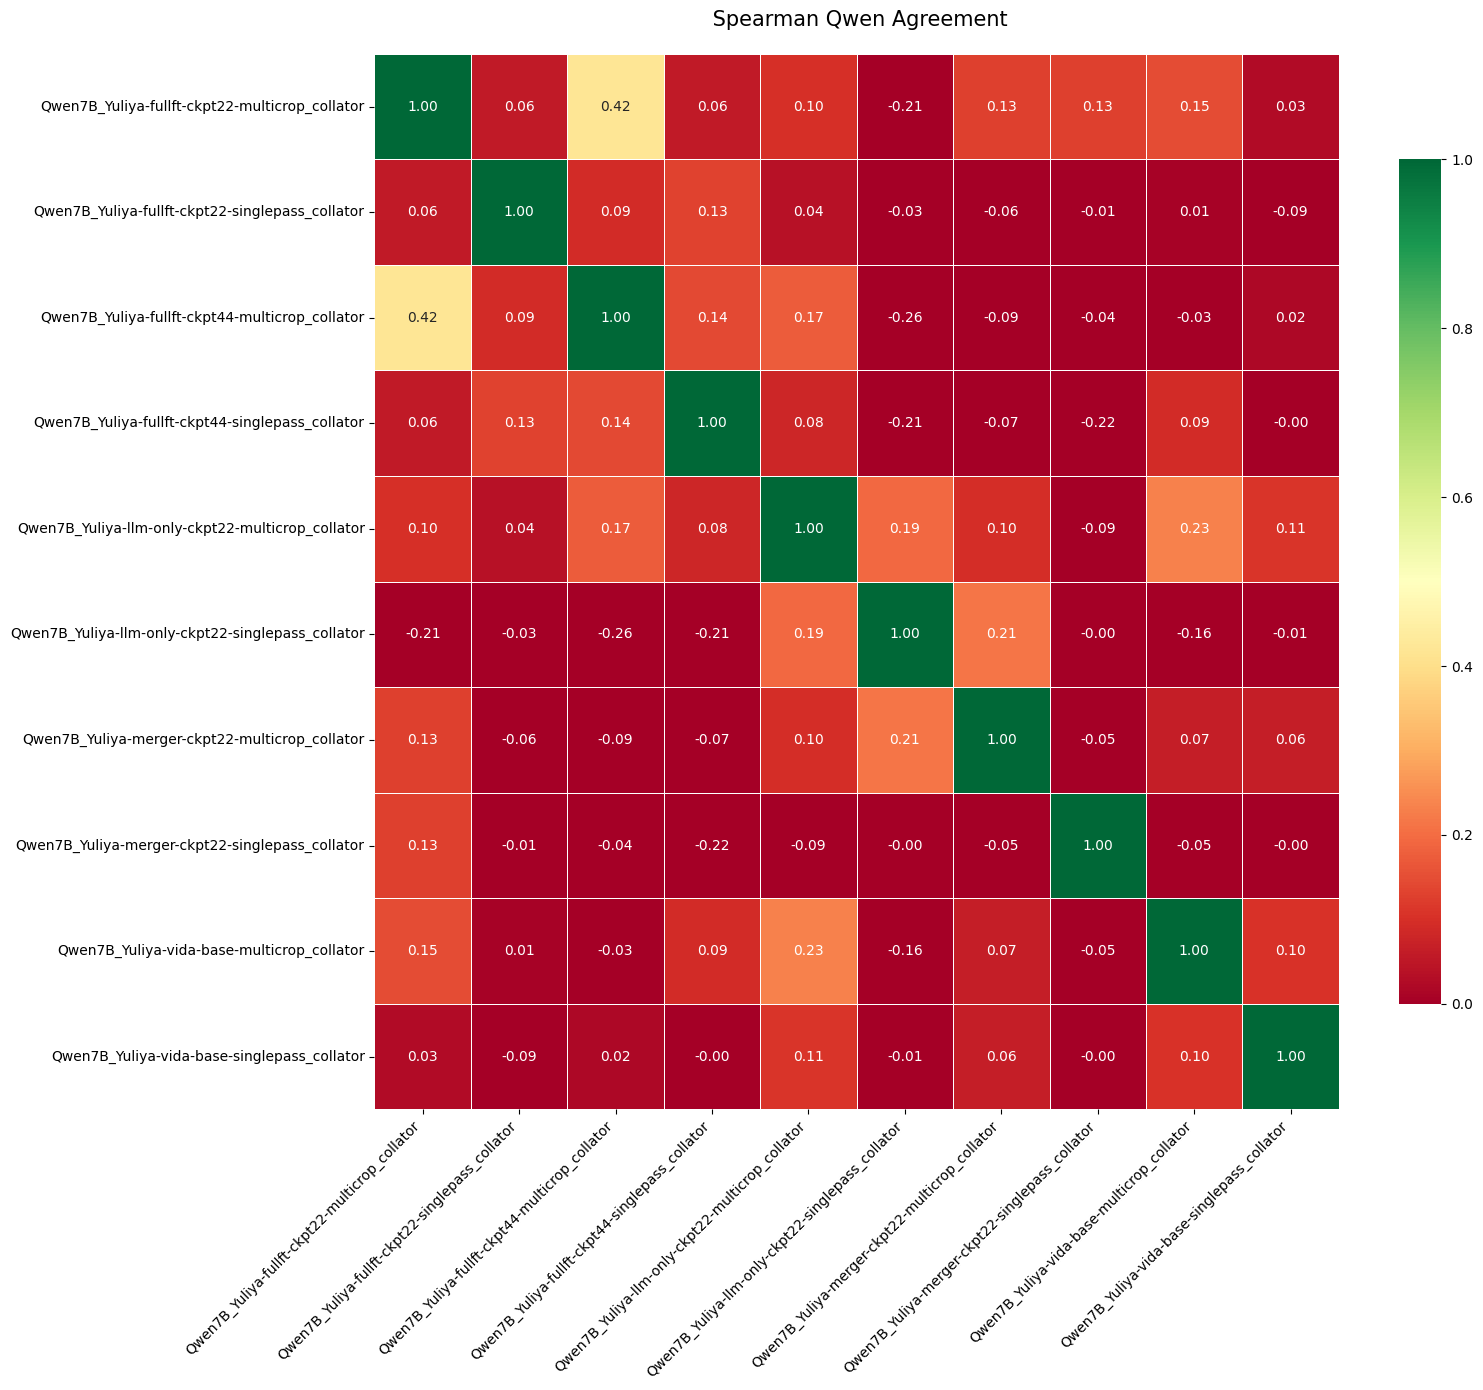

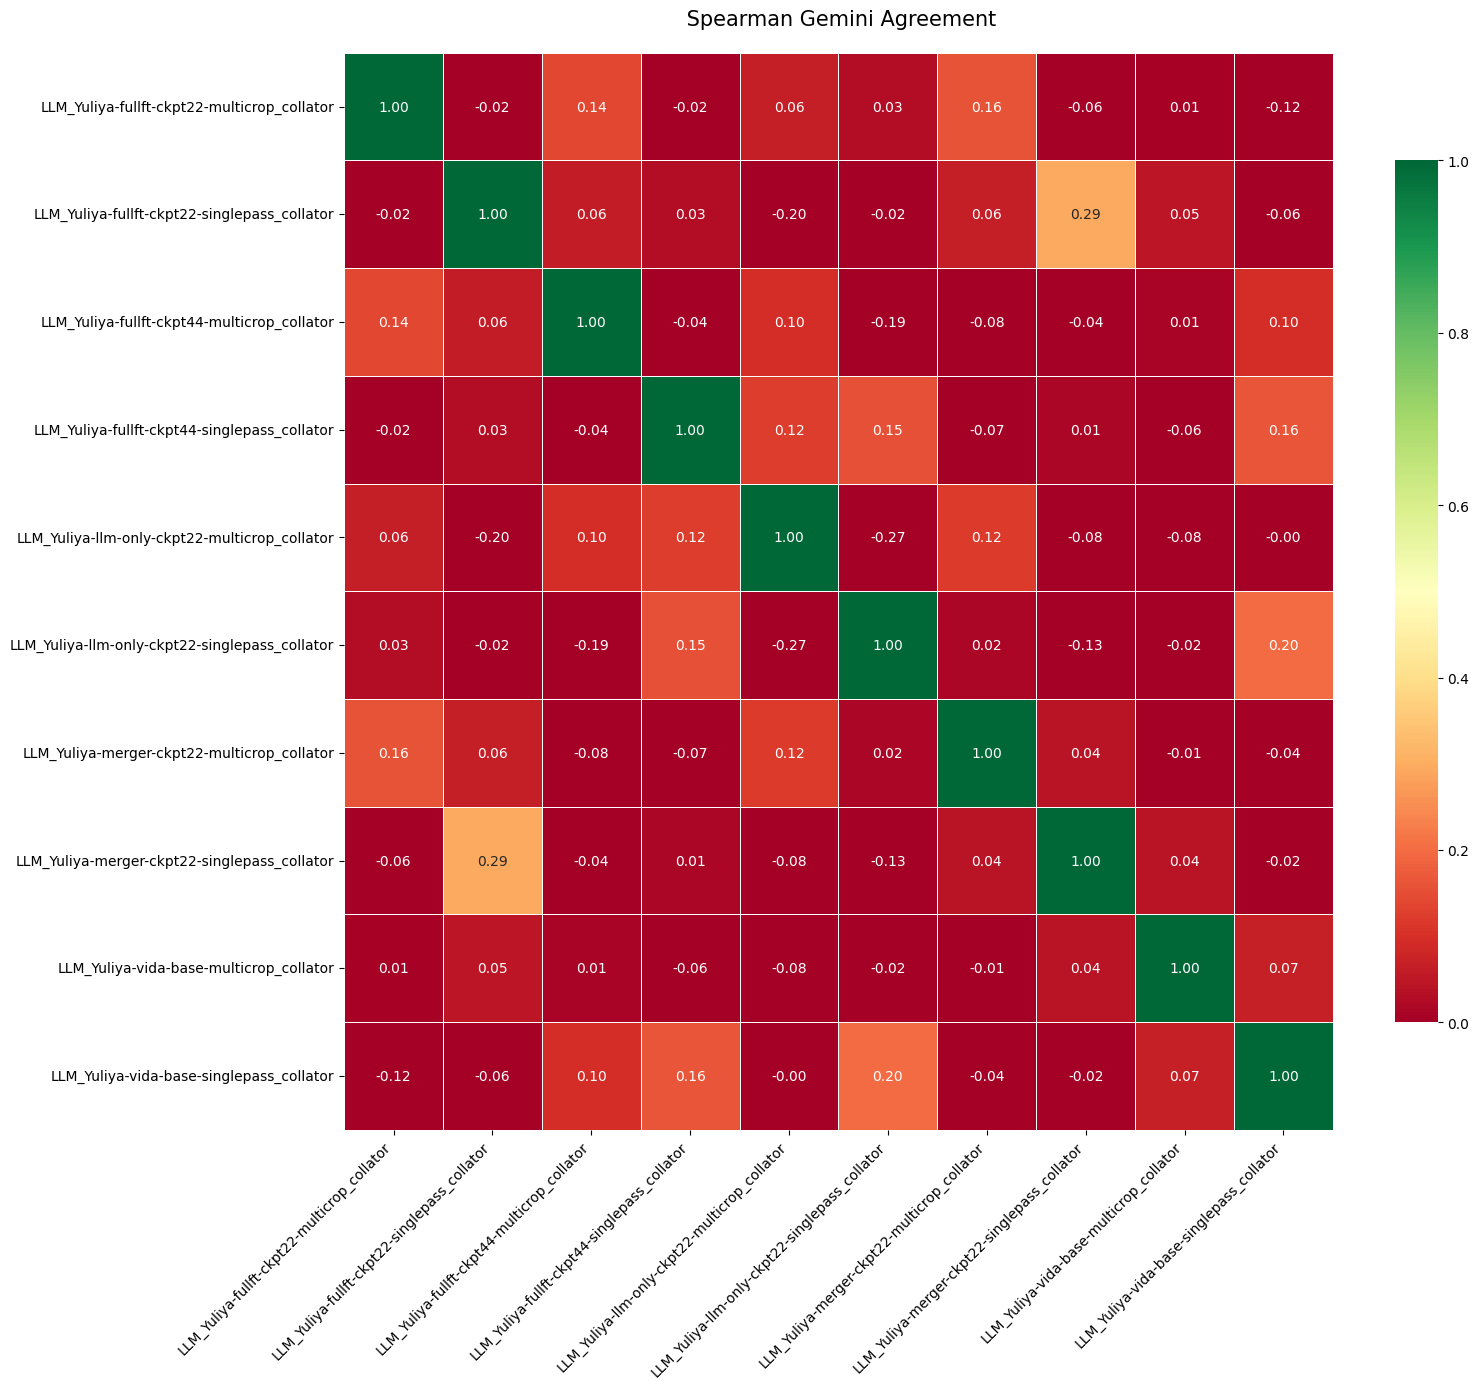

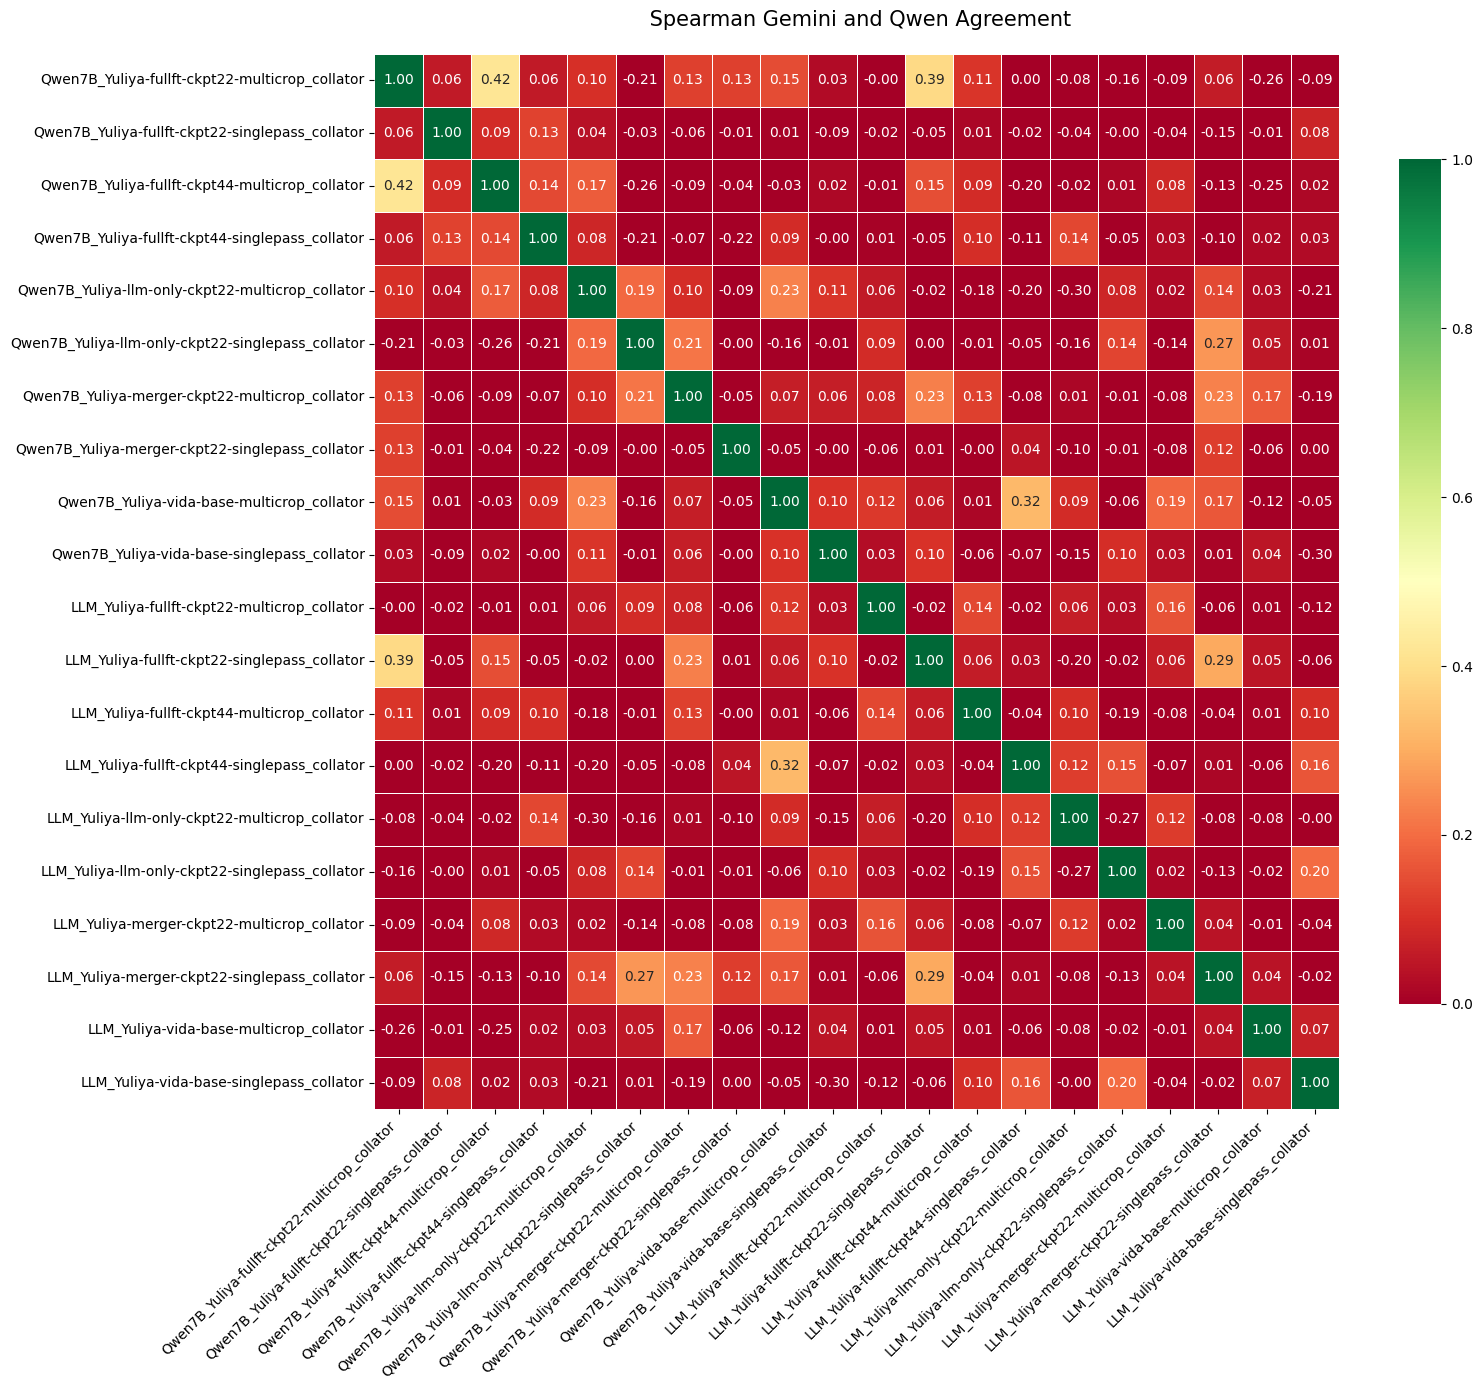

In [168]:
comp_df = build_comparison_df(['results_Qwen7B'])

plot_agreement_heatmap(comp_df, title=" Spearman Qwen Agreement")

comp_df = build_comparison_df(['results_big_LLM'])

plot_agreement_heatmap(comp_df, title=" Spearman Gemini Agreement")

comp_df = build_comparison_df(['results_Qwen7B', 'results_big_LLM'])

plot_agreement_heatmap(comp_df, title=" Spearman Gemini and Qwen Agreement")

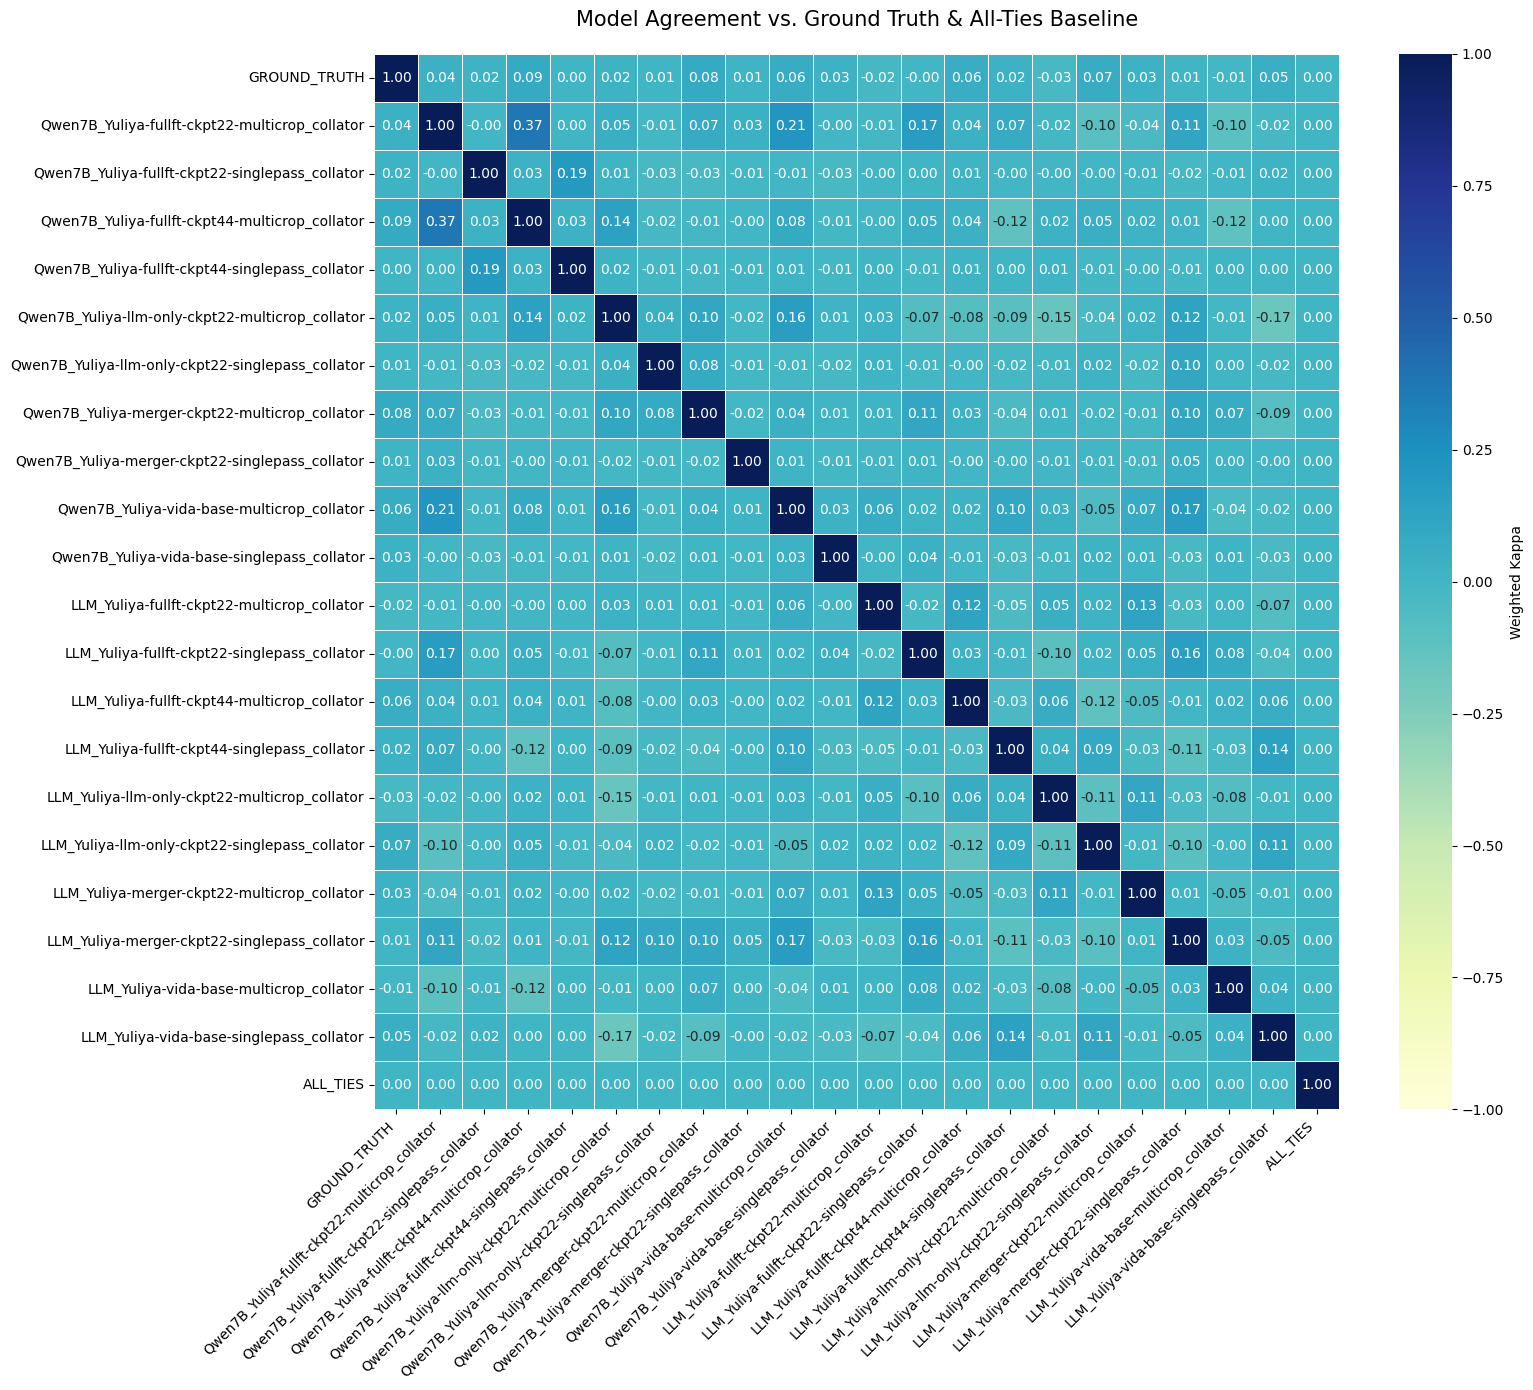

In [169]:
DIMENSIONS = ['Noise', 'Sharpness', 'Details', 'Dynamic Range', 'Exposure', 
              'Contrast', 'Banding', 'White Balance', 'Saturation', 'Ghost']

def label_to_score(val):
    if pd.isna(val): return np.nan
    val = str(val).strip()
    if '=>' in val or '>=' in val: return 1
    if '=<' in val or '<=' in val: return -1
    if '<' in val: return -2
    if '>' in val: return 2
    if '=' in val: return 0
    return np.nan


def build_comparison_df(directories, gt_file='TCL_evaluation_dataset.xlsx'):
    all_models_data = []
    
    df_gt = pd.read_excel(gt_file, skiprows=7)
    df_gt['scene_id'] = df_gt['Scene'].apply(lambda x: str(x).zfill(3))
    
    gt_melted = df_gt.melt(id_vars=['scene_id'], value_vars=DIMENSIONS, 
                          var_name='Dimension', value_name='Label')
    gt_melted['score'] = gt_melted['Label'].apply(label_to_score)
    gt_melted['key'] = gt_melted['scene_id'] + "_" + gt_melted['Dimension']
    
    gt_series = gt_melted.drop_duplicates('key').set_index('key')['score']
    gt_series.name = "GROUND_TRUTH"
    all_models_data.append(gt_series)

    for folder in directories:
        if not os.path.exists(folder): continue
        
        for file_name in os.listdir(folder):
            if not file_name.endswith('.csv'): continue
            
            model_label = f"{folder.split('_')[-1]}_{file_name.replace('.csv', '')}"
            df = pd.read_csv(os.path.join(folder, file_name))
            df['scene_id'] = df['scene_id'].apply(lambda x: str(x).zfill(3))
            
            df_melted = df.melt(id_vars=['scene_id'], var_name='Dimension', value_name='Label')
            df_melted['score'] = df_melted['Label'].apply(label_to_score)
            df_melted['key'] = df_melted['scene_id'] + "_" + df_melted['Dimension']
            
            model_series = df_melted.drop_duplicates('key').set_index('key')['score']
            model_series.name = model_label
            all_models_data.append(model_series)

    comparison_df = pd.concat(all_models_data, axis=1)
    
    comparison_df['ALL_TIES'] = 0
    
    return comparison_df


def calculate_agreement_matrix(comparison_df):
    models = comparison_df.columns
    n = len(models)
    agreement_matrix = pd.DataFrame(np.zeros((n, n)), index=models, columns=models)
    
    for i in range(n):
        for j in range(i, n):
            model_a = models[i]
            model_b = models[j]
            
            if i == j:
                agreement_matrix.loc[model_a, model_b] = 1.0
                continue

            data_subset = comparison_df[[model_a, model_b]].dropna()
            
            if len(data_subset) > 0:
                y1 = data_subset[model_a].astype(int).values
                y2 = data_subset[model_b].astype(int).values
                
                kappa = cohen_kappa_score(
                    y1, y2, 
                    weights='linear',
                    labels=[-2, -1, 0, 1, 2]
                )
            else:
                kappa = 0.0
                
            agreement_matrix.loc[model_a, model_b] = kappa
            agreement_matrix.loc[model_b, model_a] = kappa
            
    return agreement_matrix

def plot_agreement_heatmap(comparison_df, title="Inter-Model Agreement (Quadratic Weighted Kappa)"):
    agreement_matrix = calculate_agreement_matrix(comparison_df)

    plt.figure(figsize=(16, 14))
    sns.heatmap(
        agreement_matrix, 
        annot=True, 
        fmt=".2f", 
        cmap='YlGnBu',
        vmin=-1, vmax=1,
        linewidths=.5,
        cbar_kws={"label": "Weighted Kappa"}
    )
    
    plt.title(title, fontsize=15, pad=20)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

comp_df = build_comparison_df(['results_Qwen7B', 'results_big_LLM'])
plot_agreement_heatmap(comp_df, title="Model Agreement vs. Ground Truth & All-Ties Baseline")